Installing packages

In [1]:
!pip install rdkit pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 38.5 MB/s eta 0:00:00:00:0100:01


Cloning repo

In [2]:
import os

REPO_ROOT = "/content/REINVENT_Boltz_Pipeline"

if not os.path.exists(REPO_ROOT):
    !git clone https://github.com/ibrahimwichka/REINVENT_Boltz_Pipeline.git {REPO_ROOT}
else:
    !git -C {REPO_ROOT} pull origin main

print(os.path.exists(REPO_ROOT))

Cloning into '/content/REINVENT_Boltz_Pipeline'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 228 (delta 62), reused 200 (delta 46), pack-reused 0 (from 0)
Receiving objects: 100% (228/228), 27.63 MiB | 24.77 MiB/s, done.
Resolving deltas: 100% (62/62), done.
True


Setting target, iteration, and data paths

In [3]:
from pathlib import Path

# --- The only lines that change between targets/iterations ---
TARGET_NAME = "P38_MAPK14"
ITERATION = 1
ACTIVES_BASELINE = "P38_MAPK14_actives_baseline_profile.csv" 
ANALYSIS_SUBFOLDER = "P38_MAPK14_analysis"
# ---------------------------------------------------------------

REPO_ROOT_PATH = Path(REPO_ROOT)
GENERATED_PATH = (REPO_ROOT_PATH / "iterations" / TARGET_NAME / str(ITERATION)
/ "generation" / "generated_molecules.csv")
BASELINE_PATH = (REPO_ROOT_PATH / "target_mols" / TARGET_NAME / "analysis"
/ ANALYSIS_SUBFOLDER / ACTIVES_BASELINE)
ANALYSIS_DIR = (REPO_ROOT_PATH / "iterations" / TARGET_NAME / str(ITERATION)
/ "analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print(GENERATED_PATH.exists())
print(BASELINE_PATH.exists())
print(ANALYSIS_DIR)

True
True
/content/REINVENT_Boltz_Pipeline/iterations/P38_MAPK14/1/analysis


Imports

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, Lipinski, QED, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator, Draw
from rdkit.Chem import FilterCatalog
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from rdkit.Chem import AllChem, MACCSkeys, Fragments 
from rdkit.Avalon import pyAvalonTools
from rdkit.ML.Cluster import Butina

sns.set_theme(style="whitegrid")


In [5]:
!mkdir -p /content/sa_score
!curl -L -o /content/sa_score/sascorer.py \
    https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
!curl -L -o /content/sa_score/fpscores.pkl.gz \
    https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  5913  100  5913    0     0  26662      0 --:--:-- --:--:-- --:--:-- 26755
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3758k  100 3758k    0     0  7238k      0 --:--:-- --:--:-- --:--:-- 7241k


Loading generated molecules and actives baseline

In [6]:
generated_raw = pd.read_csv(GENERATED_PATH)
print(TARGET_NAME, "Iteration", ITERATION, "generated:", generated_raw.shape)
generated_raw.head()

baseline = pd.read_csv(BASELINE_PATH)
print(TARGET_NAME, "actives baseline:", baseline.shape)
baseline.head()

P38_MAPK14 Iteration 1 generated: (4845, 3)
P38_MAPK14 actives baseline: (3860, 20)


,canonical_smiles,MW,cLogP,HBD,HBA,TPSA,QED,SA_score,scaffold,has_hydroxyl,has_amine,has_carbonyl,has_amide,has_halogen_F,has_halogen_Cl,has_halogen_Br,has_aromatic_ring,has_piperidine,has_piperazine,has_morpholine
0,C[C@H]1CCCCN1c1nnc2ccc(O[C@@H]3CC[C@H](NC(=O)N...,706.896,6.70340,2,9,126.97,0.163117,4.432782,O=C(Nc1ccnn1-c1cccnc1)N[C@H]1CC[C@@H](Oc2ccc3n...,False,False,True,True,False,False,False,True,True,False,False
1,Cc1ccc(C(=O)Nc2ccon2)cc1-c1ccc2c(c1)NC(=O)C2(C)C,361.401,4.13202,2,4,84.23,0.734470,2.557593,O=C1Cc2ccc(-c3cccc(C(=O)Nc4ccon4)c3)cc2N1,False,False,True,True,False,False,False,True,False,False,False
2,CC(C)c1nnc2ccc(O[C@@H]3CC[C@H](NC(=O)Nc4cc(C(C...,614.150,7.47160,3,6,118.60,0.182737,3.918636,O=C(Nc1ccnn1-c1ccccc1)N[C@H]1CC[C@@H](Oc2ccc3n...,True,False,True,True,False,True,False,True,False,False,False
3,C[C@@H]1CCC[C@H](C)N1c1nnc2ccc(O[C@@H]3CC[C@H]...,693.901,6.51460,2,8,122.67,0.179178,4.675108,O=C(Nc1ccnn1-c1cn[nH]c1)N[C@H]1CC[C@@H](Oc2ccc...,False,False,True,True,False,False,False,True,True,False,False
4,CC(C)c1nnc2ccc(O[C@@H]3CC[C@H](NC(=O)Nc4cc(C(C...,563.706,7.11260,2,5,98.37,0.229364,3.722470,O=C(Nc1ccnn1-c1ccccc1)N[C@H]1CC[C@@H](Oc2ccc3n...,False,False,True,True,False,False,False,True,False,False,False


Cleaning and canonicalizing generated molecules

In [7]:
def canonicalize(smiles):
# Return a canonical SMILES string, or None if RDKit can’t parse it
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)

def clean_generated(df_raw, smiles_col):
    df = df_raw.copy()
    df["canonical_smiles"] = df[smiles_col].apply(canonicalize)
    n_before = len(df)
    df = df.dropna(subset=["canonical_smiles"])
    df = df.drop_duplicates(subset=["canonical_smiles"]).reset_index(drop=True)
    print(f"kept {len(df)} of {n_before} rows after canonicalization + dedup")
    return df

gen_df = clean_generated(generated_raw, smiles_col="SMILES")

kept 4845 of 4845 rows after canonicalization + dedup


Recomputing descriptors, QED, SA score, scaffold, and functional
groups

In [8]:
def add_descriptors(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["MW"] = [Descriptors.MolWt(m) for m in mols]
    df["cLogP"] = [Crippen.MolLogP(m) for m in mols]
    df["HBD"] = [Lipinski.NumHDonors(m) for m in mols]
    df["HBA"] = [Lipinski.NumHAcceptors(m) for m in mols]
    df["TPSA"] = [rdMolDescriptors.CalcTPSA(m) for m in mols]
    return df

def add_qed(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["QED"] = [QED.qed(m) for m in mols]
    return df


import sys
sys.path.append("/content/sa_score")
import sascorer

def add_sa_score(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["SA_score"] = [sascorer.calculateScore(m) for m in mols]
    return df

def add_scaffold(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["scaffold"] = [
        Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(m)) for m in mols
        ]
    return df

FUNCTIONAL_GROUP_SMARTS = {
    "hydroxyl": "[OX2H]",
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carbonyl": "[CX3]=[OX1]",
    "amide": "C(=O)N",
    "halogen_F": "[#9]",
    "halogen_Cl": "[#17]",
    "halogen_Br": "[#35]",
    "aromatic_ring": "a1aaaaa1",
    "piperidine": "C1CCNCC1",
    "piperazine": "C1CNCCN1",
    "morpholine": "C1COCCN1",
    }
FUNCTIONAL_GROUP_PATTERNS = {
name: Chem.MolFromSmarts(smarts) for name, smarts in FUNCTIONAL_GROUP_SMARTS.items()
}

def add_functional_group_flags(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    for name, patt in FUNCTIONAL_GROUP_PATTERNS.items():
        df[f"has_{name}"] = [m.HasSubstructMatch(patt) for m in mols]
    return df

gen_df = add_descriptors(gen_df)
gen_df = add_qed(gen_df)
gen_df = add_sa_score(gen_df)
gen_df = add_scaffold(gen_df)
gen_df = add_functional_group_flags(gen_df)

gen_df[["MW", "cLogP", "HBD", "HBA", "TPSA", "QED", "SA_score"]].describe()

,MW,cLogP,HBD,HBA,TPSA,QED,SA_score
count,4845.000000,4845.000000,4845.000000,4845.000000,4845.000000,4845.000000,4845.000000
mean,359.067368,3.331397,1.264190,4.202890,68.194062,0.606457,3.007379
std,131.731283,2.340736,1.186547,2.123828,37.672903,0.222743,0.821383
min,71.872000,-8.113900,0.000000,0.000000,0.000000,0.010930,1.482737
25%,270.332000,1.987700,1.000000,3.000000,43.700000,0.461276,2.422573
50%,339.136000,3.120900,1.000000,4.000000,63.210000,0.656374,2.853099
75%,420.896000,4.308920,2.000000,5.000000,86.750000,0.785508,3.412839
max,1186.864000,22.365100,13.000000,26.000000,370.970000,0.946191,7.808070


Overlaid distribution comparisons

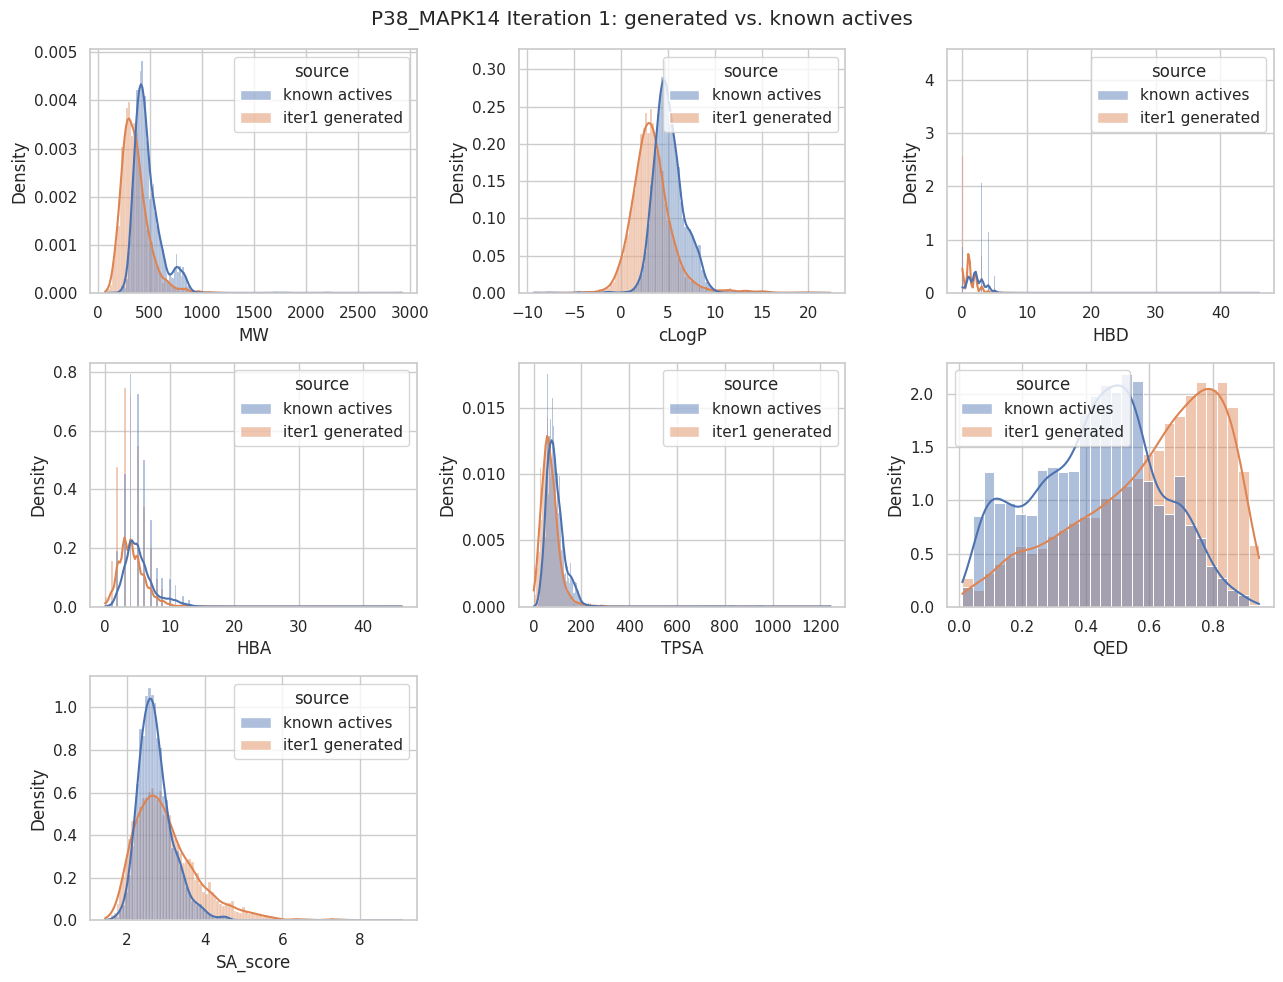

In [9]:
DESCRIPTOR_COLS = ["MW", "cLogP", "HBD", "HBA", "TPSA", "QED", "SA_score"]

compare_long = pd.concat([
    baseline[DESCRIPTOR_COLS].assign(source="known actives"),
    gen_df[DESCRIPTOR_COLS].assign(source=f"iter{ITERATION} generated"),
    ], ignore_index=True)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, col in zip(axes.flat, DESCRIPTOR_COLS):
    sns.histplot(data=compare_long, x=col, hue="source", stat="density", 
                 common_norm=False, kde=True, alpha=0.45, ax=ax)
for ax in axes.flat[len(DESCRIPTOR_COLS):]:
    ax.set_visible(False)
fig.suptitle(f"{TARGET_NAME} Iteration {ITERATION}: generated vs. known actives")
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_descriptor_comparison.png", 
            dpi=150, bbox_inches="tight")
plt.show()

Scaffold diversity and overlap

P38_MAPK14 iter1: 3684 unique scaffolds across 4845 generated molecules
P38_MAPK14 actives: 1400 unique scaffolds across 3860 molecules
Scaffolds appearing in BOTH sets: 9


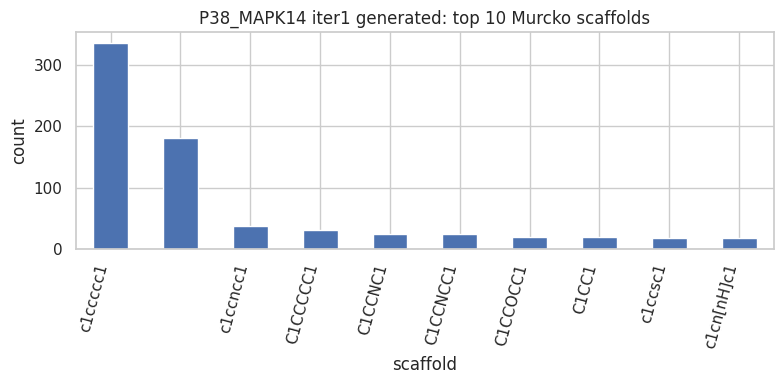

In [10]:
n_gen_scaffolds = gen_df["scaffold"].nunique()
n_act_scaffolds = baseline["scaffold"].nunique()
shared_scaffolds = set(gen_df["scaffold"]) & set(baseline["scaffold"])

print(f"{TARGET_NAME} iter{ITERATION}: {n_gen_scaffolds} unique scaffolds "
    f"across {len(gen_df)} generated molecules")
print(f"{TARGET_NAME} actives: {n_act_scaffolds} unique scaffolds "
    f"across {len(baseline)} molecules")
print(f"Scaffolds appearing in BOTH sets: {len(shared_scaffolds)}")

top_gen_scaffolds = gen_df["scaffold"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
top_gen_scaffolds.plot(kind="bar", ax=ax)
ax.set_ylabel("count")
ax.set_title(f"{TARGET_NAME} iter{ITERATION} generated: top 10 Murcko scaffolds")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_top_scaffolds.png", 
            dpi=150, bbox_inches="tight")
plt.show()

Functional group frequency comparison

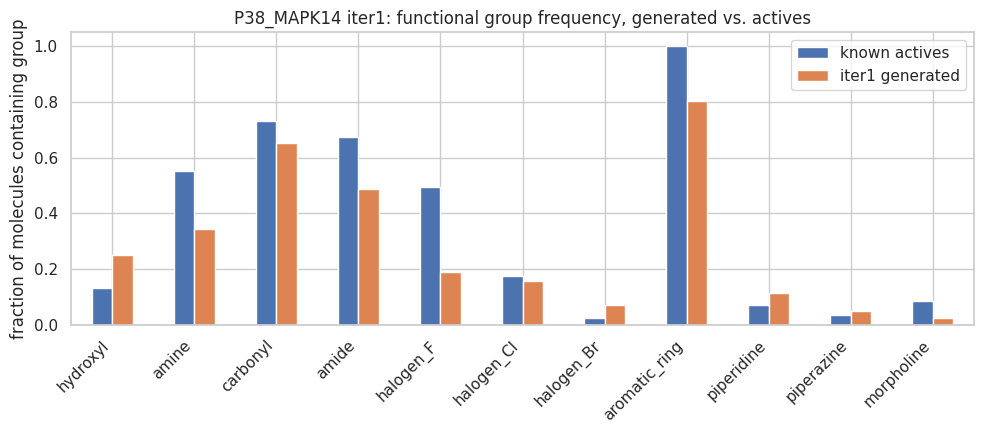

In [11]:
flag_cols = [f"has_{name}" for name in FUNCTIONAL_GROUP_SMARTS]

freq_compare = pd.DataFrame({
    "known actives": baseline[flag_cols].mean(),
    f"iter{ITERATION} generated": gen_df[flag_cols].mean(),
    })
freq_compare.index = [c.replace("has_", "") for c in freq_compare.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
freq_compare.plot(kind="bar", ax=ax)
ax.set_ylabel("fraction of molecules containing group")
ax.set_title(f"{TARGET_NAME} iter{ITERATION}: functional group frequency, " 
             "generated vs. actives")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_functional_group_frequency.png", 
            dpi=150, bbox_inches="tight")
plt.show()

Cross-set Tanimoto similarity to known actives

In [12]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def add_fingerprints(df):
    mols = [Chem.MolFromSmiles(s) for s in df["canonical_smiles"]]
    df = df.copy()
    df["fingerprint"] = [morgan_gen.GetFingerprint(m) for m in mols]
    return df

gen_df = add_fingerprints(gen_df)
baseline_fps_df = add_fingerprints(baseline.rename(columns={"canonical_smiles": 
        "canonical_smiles"}))
active_fps = list(baseline_fps_df["fingerprint"])

def nearest_active(fp):
    #Return (max Tanimoto similarity, index into baseline of the nearest active).
    sims = DataStructs.BulkTanimotoSimilarity(fp, active_fps)
    best_idx = int(np.argmax(sims))
    return sims[best_idx], best_idx

results = [nearest_active(fp) for fp in gen_df["fingerprint"]]
gen_df["nearest_active_sim"] = [r[0] for r in results]
gen_df["nearest_active_idx"] = [r[1] for r in results]

print(f"{TARGET_NAME} iter{ITERATION}: mean nearest-active Tanimoto = "
      f"{gen_df['nearest_active_sim'].mean():.3f}, "
      f"max = {gen_df['nearest_active_sim'].max():.3f}")

P38_MAPK14 iter1: mean nearest-active Tanimoto = 0.252, max = 0.619


Rediscovery hit detection

In [13]:
THETA_HIT = 0.85 # research plan Section 1.5: near-identical scaffold
THETA_EXACT = 1.0 # exact canonical SMILES match

hits = gen_df[gen_df["nearest_active_sim"] >= THETA_HIT].copy()
exact_hits = gen_df[gen_df["nearest_active_sim"] >= THETA_EXACT].copy()

print(f"{TARGET_NAME} iter{ITERATION}: {len(hits)} rediscovery hit(s) "
    f"(sim >= {THETA_HIT}) out of {len(gen_df)} generated molecules")
print(f" of which {len(exact_hits)} are exact matches (sim = 1.0)")

if len(hits) == 0:
    print("\nNo hits yet -- expected for Iteration 1. See the closest pairs below "
    "instead; re-run this exact cell on later iterations to watch this "
    "number move.")


P38_MAPK14 iter1: 0 rediscovery hit(s) (sim >= 0.85) out of 4845 generated molecules
 of which 0 are exact matches (sim = 1.0)

No hits yet -- expected for Iteration 1. See the closest pairs below instead; re-run this exact cell on later iterations to watch this number move.


Visualizing the closest pairs

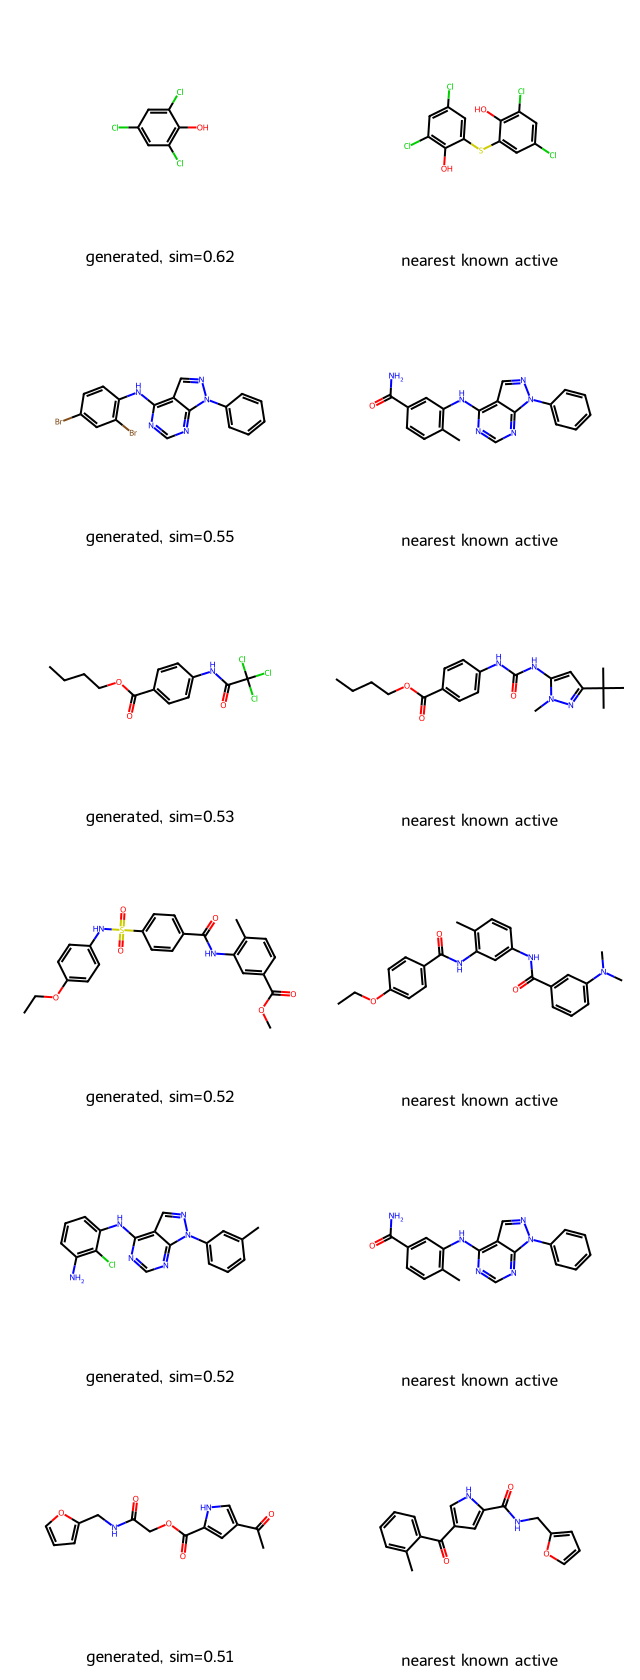

In [14]:
N_SHOW = 6
top_pairs = gen_df.sort_values("nearest_active_sim", ascending=False).head(N_SHOW)

mols_to_draw = []
legends = []
for _, row in top_pairs.iterrows():
    gen_mol = Chem.MolFromSmiles(row["canonical_smiles"])
    act_row = baseline.iloc[row["nearest_active_idx"]]
    act_mol = Chem.MolFromSmiles(act_row["canonical_smiles"])
    
    mols_to_draw += [gen_mol, act_mol]
    legends += [
        f"generated, sim={row['nearest_active_sim']:.2f}",
        "nearest known active",
    ]

img = Draw.MolsToGridImage(
    mols_to_draw, molsPerRow=2, subImgSize=(320, 280), legends=legends, 
    returnPNG=False 
    )
img.save(str(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_closest_pairs.png"))
img

PCA - Projecting generated molecules into actives' descriptor space

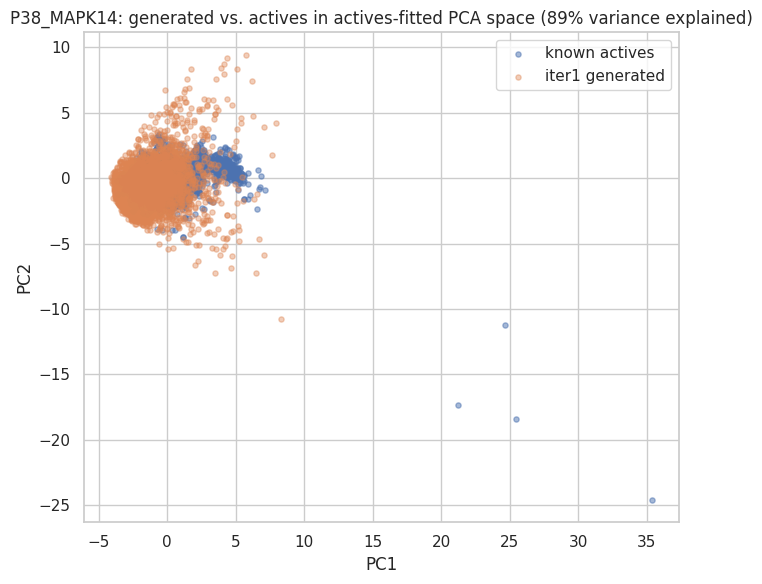

In [15]:
feature_cols = ["MW", "cLogP", "HBD", "HBA", "TPSA", "QED"]

scaler = StandardScaler().fit(baseline[feature_cols])
pca = PCA(n_components=2).fit(scaler.transform(baseline[feature_cols]))

act_pca = pca.transform(scaler.transform(baseline[feature_cols]))
gen_pca = pca.transform(scaler.transform(gen_df[feature_cols]))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(act_pca[:, 0], act_pca[:, 1], alpha=0.5, s=14, label="known actives")
ax.scatter(gen_pca[:, 0], gen_pca[:, 1], alpha=0.4, s=14,
           label=f"iter{ITERATION} generated")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"{TARGET_NAME}: generated vs. actives in actives-fitted PCA space "
             f"({pca.explained_variance_ratio_.sum():.0%} variance explained)")
ax.legend()
fig.tight_layout()
fig.savefig(ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_pca_comparison.png", 
            dpi=150, bbox_inches="tight")
plt.show()

PAINS screening on closest candidates

In [16]:
params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog.FilterCatalog(params)

def pains_flags(smiles_list):
    flagged = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        match = pains_catalog.GetFirstMatch(mol)
        flagged.append(match.GetDescription() if match else None)
    return flagged

top_pairs = top_pairs.copy()
top_pairs["pains_flag"] = pains_flags(top_pairs["canonical_smiles"])
top_pairs[["canonical_smiles", "nearest_active_sim", "pains_flag"]]

,canonical_smiles,nearest_active_sim,pains_flag
1341,Oc1c(Cl)cc(Cl)cc1Cl,0.619048,None
1229,Brc1ccc(Nc2ncnc3c2cnn3-c2ccccc2)c(Br)c1,0.550000,None
1184,CCCCOC(=O)c1ccc(NC(=O)C(Cl)(Cl)Cl)cc1,0.527273,None
813,CCOc1ccc(NS(=O)(=O)c2ccc(C(=O)Nc3cc(C(=O)OC)cc...,0.523077,None
4313,Cc1cccc(-n2ncc3c(Nc4cccc(N)c4Cl)ncnc32)c1,0.515625,None
3362,CC(=O)c1c[nH]c(C(=O)OCC(=O)NCc2ccco2)c1,0.508197,None


More properties (clustering based on molecular fingerprints and functional groups)


[morgan] 4440 clusters found (4198 single-molecule clusters, largest = 28 molecules)


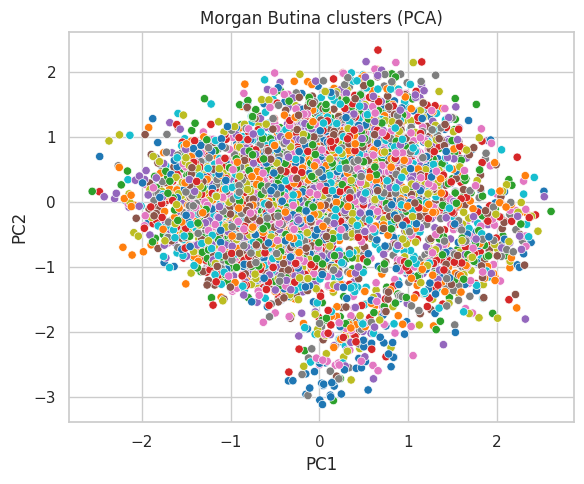

Top functional groups per cluster (morgan)

Cluster 0 (n=28):
fr_unbrch_alkane    20.678571
fr_allylic_oxid      8.857143
fr_ether             2.178571
fr_C_O               2.142857
fr_C_O_noCOO         2.035714

Cluster 1 (n=11):
fr_benzene      3.363636
fr_C_O_noCOO    2.000000
fr_C_O          2.000000
fr_amide        2.000000
fr_NH0          1.909091

Cluster 2 (n=10):
fr_C_O          4.1
fr_C_O_noCOO    3.7
fr_amide        2.9
fr_NH1          2.5
fr_ether        1.5

Cluster 3 (n=10):
fr_C_O          5.0
fr_NH1          4.3
fr_C_O_noCOO    3.4
fr_amide        3.3
fr_Ar_N         1.9

Cluster 4 (n=7):
fr_benzene      3.000000
fr_ether        2.285714
fr_NH0          1.857143
fr_C_O          1.285714
fr_C_O_noCOO    1.142857

Cluster 5 (n=7):
fr_benzene      1.714286
fr_C_O_noCOO    1.285714
fr_NH1          1.285714
fr_amide        1.285714
fr_C_O          1.285714

Cluster 6 (n=6):
fr_unbrch_alkane    2.166667
fr_halogen          1.333333
fr_benzene          1.166667
fr_C_O_noCOO   

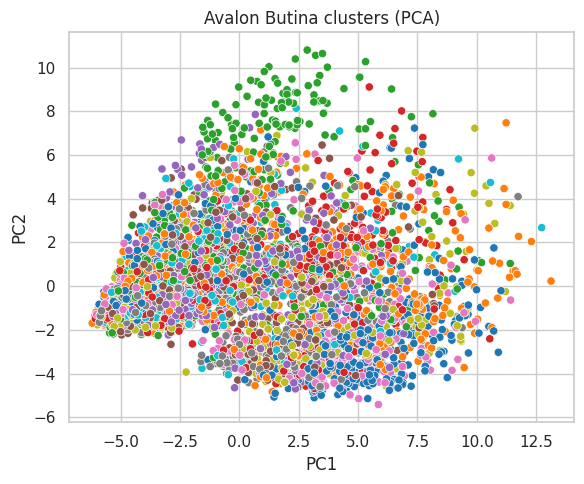

Top functional groups per cluster (avalon)

Cluster 0 (n=230):
fr_NH0            3.400000
fr_Ar_N           2.852174
fr_benzene        1.078261
fr_aryl_methyl    1.069565
fr_C_O            0.921739

Cluster 1 (n=146):
fr_NH0          3.821918
fr_Ar_N         3.191781
fr_bicyclic     1.493151
fr_benzene      1.479452
fr_imidazole    0.890411

Cluster 2 (n=126):
fr_bicyclic     2.103175
fr_ether        2.047619
fr_C_O          2.039683
fr_C_O_noCOO    1.873016
fr_NH0          1.373016

Cluster 3 (n=124):
fr_benzene     1.564516
fr_Ar_N        1.500000
fr_NH1         1.419355
fr_NH0         1.403226
fr_bicyclic    1.282258

Cluster 4 (n=122):
fr_benzene      1.909836
fr_NH0          1.188525
fr_NH1          1.081967
fr_sulfonamd    1.032787
fr_C_O          0.918033

Cluster 5 (n=107):
fr_C_O          1.859813
fr_NH0          1.831776
fr_C_O_noCOO    1.766355
fr_amide        1.766355
fr_benzene      1.467290

Cluster 6 (n=93):
fr_NH0        3.526882
fr_Ar_N       3.118280
fr_benzene    1.0

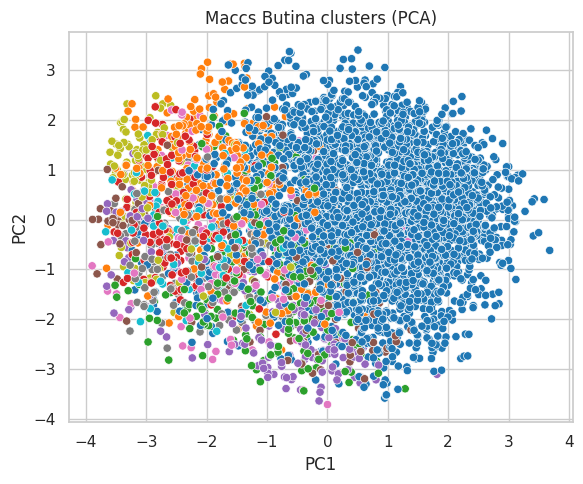

Top functional groups per cluster (maccs)

Cluster 0 (n=3252):
fr_NH0          2.170664
fr_Ar_N         1.273678
fr_benzene      1.226630
fr_C_O          1.170972
fr_C_O_noCOO    1.077183

Cluster 1 (n=231):
fr_unbrch_alkane    2.294372
fr_ether            0.844156
fr_C_O              0.662338
fr_C_O_noCOO        0.580087
fr_NH1              0.562771

Cluster 2 (n=183):
fr_NH0         1.163934
fr_Ar_N        1.054645
fr_benzene     0.912568
fr_bicyclic    0.830601
fr_NH1         0.803279

Cluster 3 (n=127):
fr_ether        2.330709
fr_benzene      1.606299
fr_C_O          1.173228
fr_bicyclic     1.102362
fr_C_O_noCOO    1.055118

Cluster 4 (n=122):
fr_benzene     2.295082
fr_NH0         2.213115
fr_Ar_N        1.950820
fr_bicyclic    1.950820
fr_aniline     0.934426

Cluster 5 (n=113):
fr_benzene      1.141593
fr_NH1          0.805310
fr_NH0          0.761062
fr_halogen      0.752212
fr_sulfonamd    0.654867

Cluster 6 (n=93):
fr_benzene     1.354839
fr_ether       1.322581
fr_C_O    

In [20]:
gen_df["mol"] = gen_df["canonical_smiles"].apply(Chem.MolFromSmiles)
mols = gen_df["mol"].tolist()

# Computing fingerprints (Morgan, Avalon, MACCS)
def get_fingerprints(mols, fp_type="morgan", n_bits=2048, radius=2):
    # Returns a list of RDKit fingerprint vectors 
    if fp_type == "morgan":
        if "fingerprint" in gen_df.columns:
            return list(gen_df["fingerprint"])
        generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
        return [generator.GetFingerprint(mol) for mol in mols]
    elif fp_type == "avalon":
        return [pyAvalonTools.GetAvalonFP(mol, nBits=n_bits) for mol in mols]
    elif fp_type == "maccs":
        return [MACCSkeys.GenMACCSKeys(mol) for mol in mols] 
    else:
        raise ValueError(f"Unknown fp_type: {fp_type}")


# Butina clustering on Tanimoto distance
def butina_cluster(fps, cutoff=0.6):
    # cutoff = Tanimoto distance threshold (1 - similarity) 
    n = len(fps)
    dists = []
    for i in range(1, n):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - s for s in sims])

    clusters = Butina.ClusterData(dists, n, cutoff, isDistData=True)
    clusters_by_size = sorted(clusters, key=len, reverse=True)

    labels = np.empty(n, dtype=int)
    for cluster_id, member_indices in enumerate(clusters_by_size):
        for idx in member_indices:
            labels[idx] = cluster_id
    return labels, clusters_by_size

# Functional group counting 
FRAGMENT_FUNCS = {
    name: func for name, func in Fragments.__dict__.items() if name.startswith("fr_")
}


def compute_functional_groups(mols):
    rows = [{name: func(mol) for name, func in FRAGMENT_FUNCS.items()} for mol in mols]
    return pd.DataFrame(rows)


def top_functional_groups_per_cluster(fg_df, labels, top_n=5):
    fg_df = fg_df.copy()
    fg_df["cluster"] = labels
    results = {}
    for cluster_id, group in fg_df.groupby("cluster"):
        mean_counts = group.drop(columns="cluster").mean().sort_values(ascending=False)
        results[cluster_id] = mean_counts[mean_counts > 0].head(top_n)
    return results


# Clustering visualization
def fps_to_numpy(fps):
    arrs = []
    for fp in fps:
        arr = np.zeros((1,), dtype=int)
        DataStructs.ConvertToNumpyArray(fp, arr)
        arrs.append(arr)
    return np.array(arrs)


def plot_clusters_pca(fps, labels, title, save_path=None): 
    coords = PCA(n_components=2, random_state=42).fit_transform(fps_to_numpy(fps))
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=labels, palette="tab10", legend=False)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    if save_path: 
        plt.savefig(save_path, dpi=150) 
    plt.show()

# Summary of most common functional groups for the clusters within the different fingerprint types
def summarize_clustering(clusters, fg_df, labels, fp_type):
    n_clusters = len(clusters)
    n_single = sum(1 for c in clusters if len(c) == 1)
    biggest_id = 0  # sorted by size
    biggest_size = len(clusters[0])

    top_groups_biggest = top_functional_groups_per_cluster(fg_df, labels, top_n=3)[biggest_id]
    dominant_group = top_groups_biggest.index[0] if len(top_groups_biggest) else "none"

    return {
        "fingerprint": fp_type,
        "n_molecules": len(labels),
        "n_clusters": n_clusters,
        "n_single_molecule_clusters": n_single,
        "pct_single_molecule": round(100 * n_single / len(labels), 1),
        "biggest_cluster_size": biggest_size,
        "biggest_cluster_dominant_group": dominant_group,
    }


# Generating graph and summary data for each fingerprint type 
FP_TYPES = ["morgan", "avalon", "maccs"]
CUTOFF = 0.6  # Tanimoto distance threshold; can change  

fg_df = compute_functional_groups(mols)
all_labels = {}
summary_rows = []

for fp_type in FP_TYPES:
    fps = get_fingerprints(mols, fp_type=fp_type)
    labels, clusters = butina_cluster(fps, cutoff=CUTOFF)

    gen_df[f"cluster_{fp_type}"] = labels
    all_labels[fp_type] = labels
    summary_rows.append(summarize_clustering(clusters, fg_df, labels, fp_type))

    n_single = sum(1 for c in clusters if len(c) == 1)
    print(f"\n[{fp_type}] {len(clusters)} clusters found "
          f"({n_single} single-molecule clusters, largest = {len(clusters[0])} molecules)")

    plot_clusters_pca(
        fps, labels, title=f"{fp_type.capitalize()} Butina clusters (PCA)",
        save_path=f"{ANALYSIS_DIR}/{fp_type}_clusters_pca.png", 
    )

    print(f"Top functional groups per cluster ({fp_type})")
    top_groups = top_functional_groups_per_cluster(fg_df, labels)
    lines = []
    for cluster_id in sorted(set(labels)):
        n_in_cluster = int((labels == cluster_id).sum())
        block = f"\nCluster {cluster_id} (n={n_in_cluster}):\n{top_groups[cluster_id].to_string()}"
        print(block)
        lines.append(block)

    with open(f"{ANALYSIS_DIR}/{fp_type}_functional_groups.txt", "w") as f:
        f.write("\n".join(lines))



In [21]:
# General summary table
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{ANALYSIS_DIR}/clustering_summary.csv", index=False)
print("\nClustering summary")
summary_df


Clustering summary


,fingerprint,n_molecules,n_clusters,n_single_molecule_clusters,pct_single_molecule,biggest_cluster_size,biggest_cluster_dominant_group
0,morgan,4845,4440,4198,86.6,28,fr_unbrch_alkane
1,avalon,4845,1402,939,19.4,230,fr_NH0
2,maccs,4845,99,32,0.7,3252,fr_NH0


In [22]:
# Most common functional group in the top 20 hits (based on Tanimoto similarity) 
TOP_N_HITS = 20
 
top_hits = gen_df.sort_values("nearest_active_sim", ascending=False).head(TOP_N_HITS).reset_index(drop=True)
top_hits_fg = compute_functional_groups(top_hits["mol"].tolist())
 
# For each hit, find its own single most common functional group (by count)
def top_group_for_row(row):
    if row.max() == 0:
        return "none"
    return row.idxmax().replace("fr_", "")
 
top_hits["top_functional_group"] = top_hits_fg.apply(top_group_for_row, axis=1)
top_hits.drop(columns="mol").to_csv(f"{ANALYSIS_DIR}/top_{TOP_N_HITS}_hits.csv", index=False)
 
print(f"Top {TOP_N_HITS} hits by nearest_active_sim")
top_hits[["canonical_smiles", "nearest_active_sim", "top_functional_group"]]

Top 20 hits by nearest_active_sim


,canonical_smiles,nearest_active_sim,top_functional_group
0,Oc1c(Cl)cc(Cl)cc1Cl,0.619048,halogen
1,Brc1ccc(Nc2ncnc3c2cnn3-c2ccccc2)c(Br)c1,0.550000,NH0
2,CCCCOC(=O)c1ccc(NC(=O)C(Cl)(Cl)Cl)cc1,0.527273,halogen
3,CCOc1ccc(NS(=O)(=O)c2ccc(C(=O)Nc3cc(C(=O)OC)cc...,0.523077,benzene
4,Cc1cccc(-n2ncc3c(Nc4cccc(N)c4Cl)ncnc32)c1,0.515625,NH0
5,CC(=O)c1c[nH]c(C(=O)OCC(=O)NCc2ccco2)c1,0.508197,C_O
6,O=C(Nc1cccc(NCC2CCCCC2)c1)c1cccs1,0.500000,NH1
7,NNC(=O)c1ccc2c(c1)OCCO2,0.489362,ether
8,COc1cc2cc[nH]c2cc1C(=O)N1CC2CCC(O)(c3ccccc3)C2C1,0.485714,bicyclic
9,O=Cc1ccccc1-c1ccc(C(=O)Nc2nncs2)cc1,0.483871,C_O


Assembling and saving comparison profile

In [23]:
comparison_cols = [
    "canonical_smiles", "MW", "cLogP", "HBD", "HBA", "TPSA",
    "QED", "SA_score", "scaffold", "nearest_active_sim",
    ] + flag_cols

comparison = gen_df[comparison_cols]
comparison_out = ANALYSIS_DIR / f"{TARGET_NAME}_iter{ITERATION}_comparison_profile.csv"
comparison.to_csv(comparison_out, index=False)

print("saved:", comparison_out)
print(f"rediscovery hits (sim >= {THETA_HIT}):", len(hits))

saved: /content/REINVENT_Boltz_Pipeline/iterations/P38_MAPK14/1/analysis/P38_MAPK14_iter1_comparison_profile.csv
rediscovery hits (sim >= 0.85): 0


Bringing everything to laptop (figures, csv)

In [24]:
import shutil
from google.colab import files

zip_base = f"/content/{TARGET_NAME}_iter{ITERATION}_analysis"
shutil.make_archive(zip_base, "zip", ANALYSIS_DIR)
files.download(f"{zip_base}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>